# Research Notebook 08: Final Dataset Overview
**Delhi NCR Trust-Aware Recommender System Dataset**

This notebook validates the final merged dataset (`final_hotel_dataset.csv`), performing schema validation, missing value mapping, and correlation checks across the entire features set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300, 'figure.figsize': (10, 6)})
FIG_DIR = '../reports/figures/'
print('Imports complete.')

Imports complete.


## 1. Load Final Hotel Dataset & Schema Validation
We verify that the final merged dataset perfectly adheres to our schema.

In [2]:
df_final = pd.read_csv('../../data/exports/final_hotel_dataset.csv')
df_schema = pd.read_csv('../../data/exports/final_dataset_schema.csv')

print(f'Final Dataset Shape: {df_final.shape}')
print(f'Schema Expected Columns: {len(df_schema)}')

# Column check
missing_cols = set(df_schema['Column Name']) - set(df_final.columns)
extra_cols = set(df_final.columns) - set(df_schema['Column Name'])
print('Schema check:')
print('Missing columns:', missing_cols)
print('Extra columns:', extra_cols)
assert len(missing_cols) == 0, 'Schema mismatch!'

Final Dataset Shape: (1661, 26)
Schema Expected Columns: 26
Schema check:
Missing columns: set()
Extra columns: set()


## 2. Global Missing Value Map
We visualize missing values across the final merged dataset.

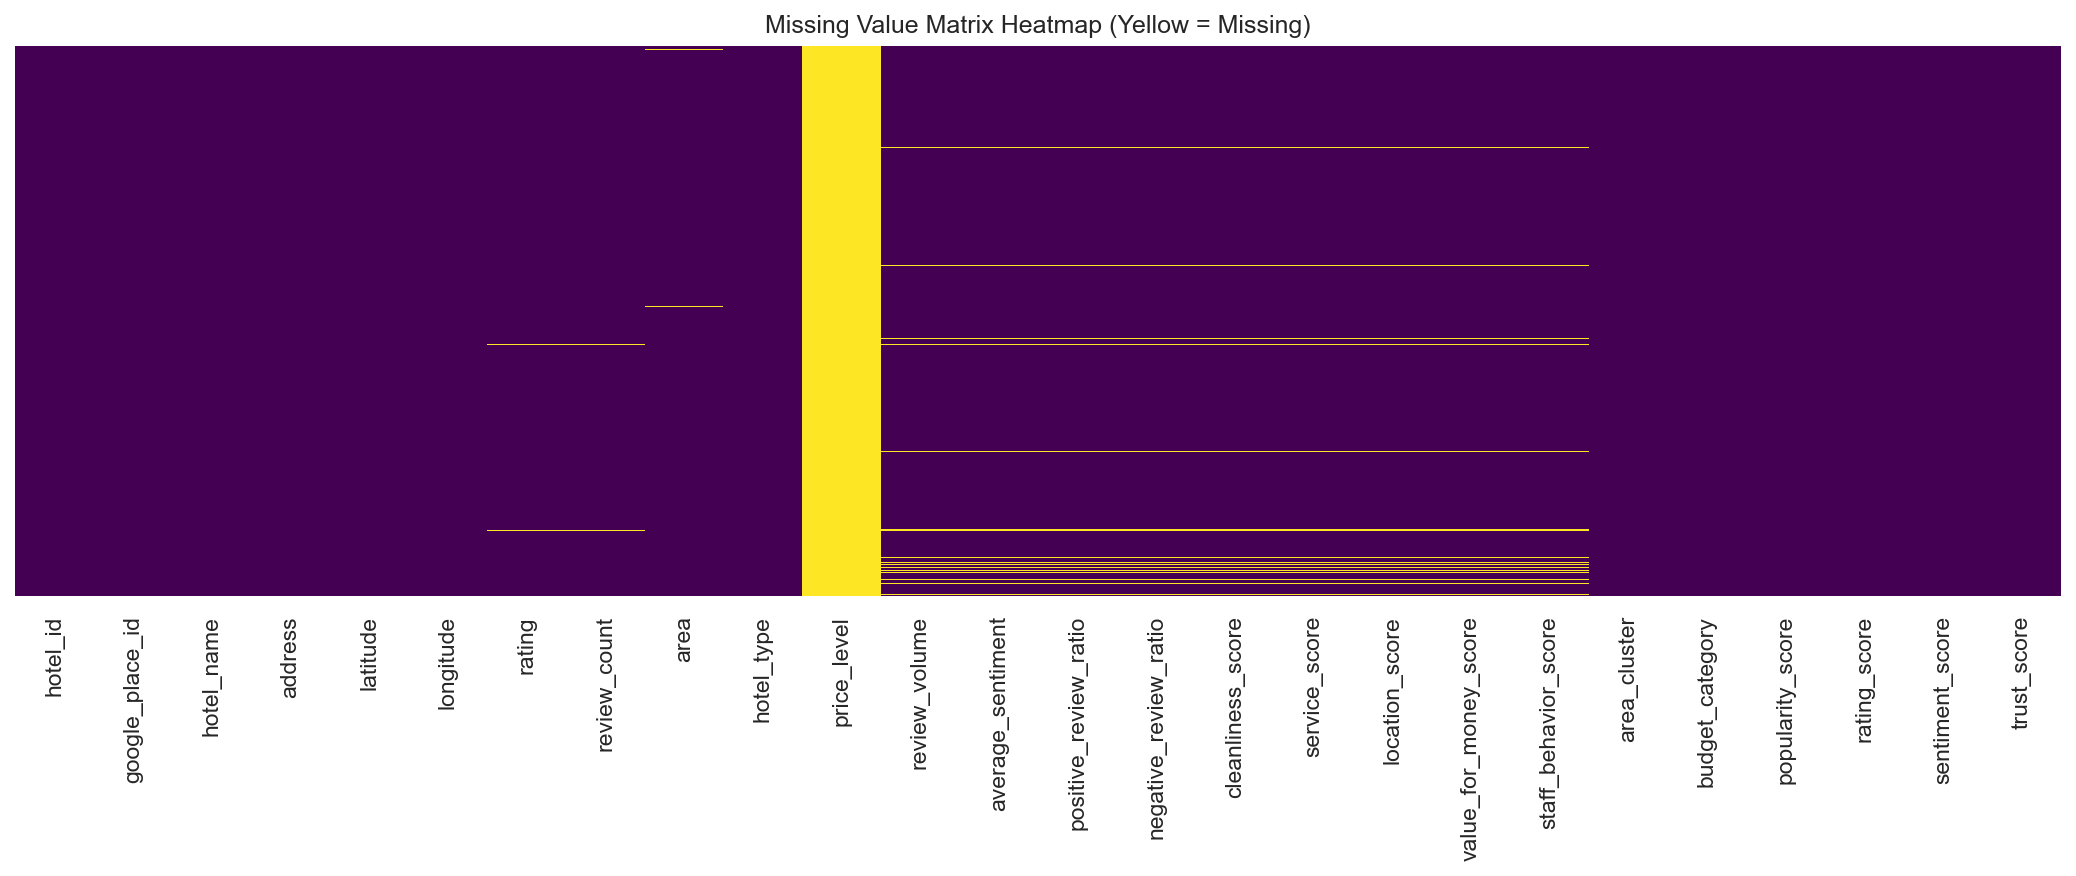

In [3]:
plt.figure(figsize=(14, 6))
sns.heatmap(df_final.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Matrix Heatmap (Yellow = Missing)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '08_missing_heatmap.png'))
plt.show()

**Interpretation & Key Insight:**
> `price_level` is completely yellow (100% missing). A thin stripe of yellow (~2.59%) corresponds to hotels with no review text, which therefore lack aggregated aspect-based sentiment scores. We will need to impute or handle these missing scores (e.g. fill with area averages or overall dataset medians) before similarity computation.

## 3. Global Correlation Analysis
We calculate correlations across all numerical attributes.

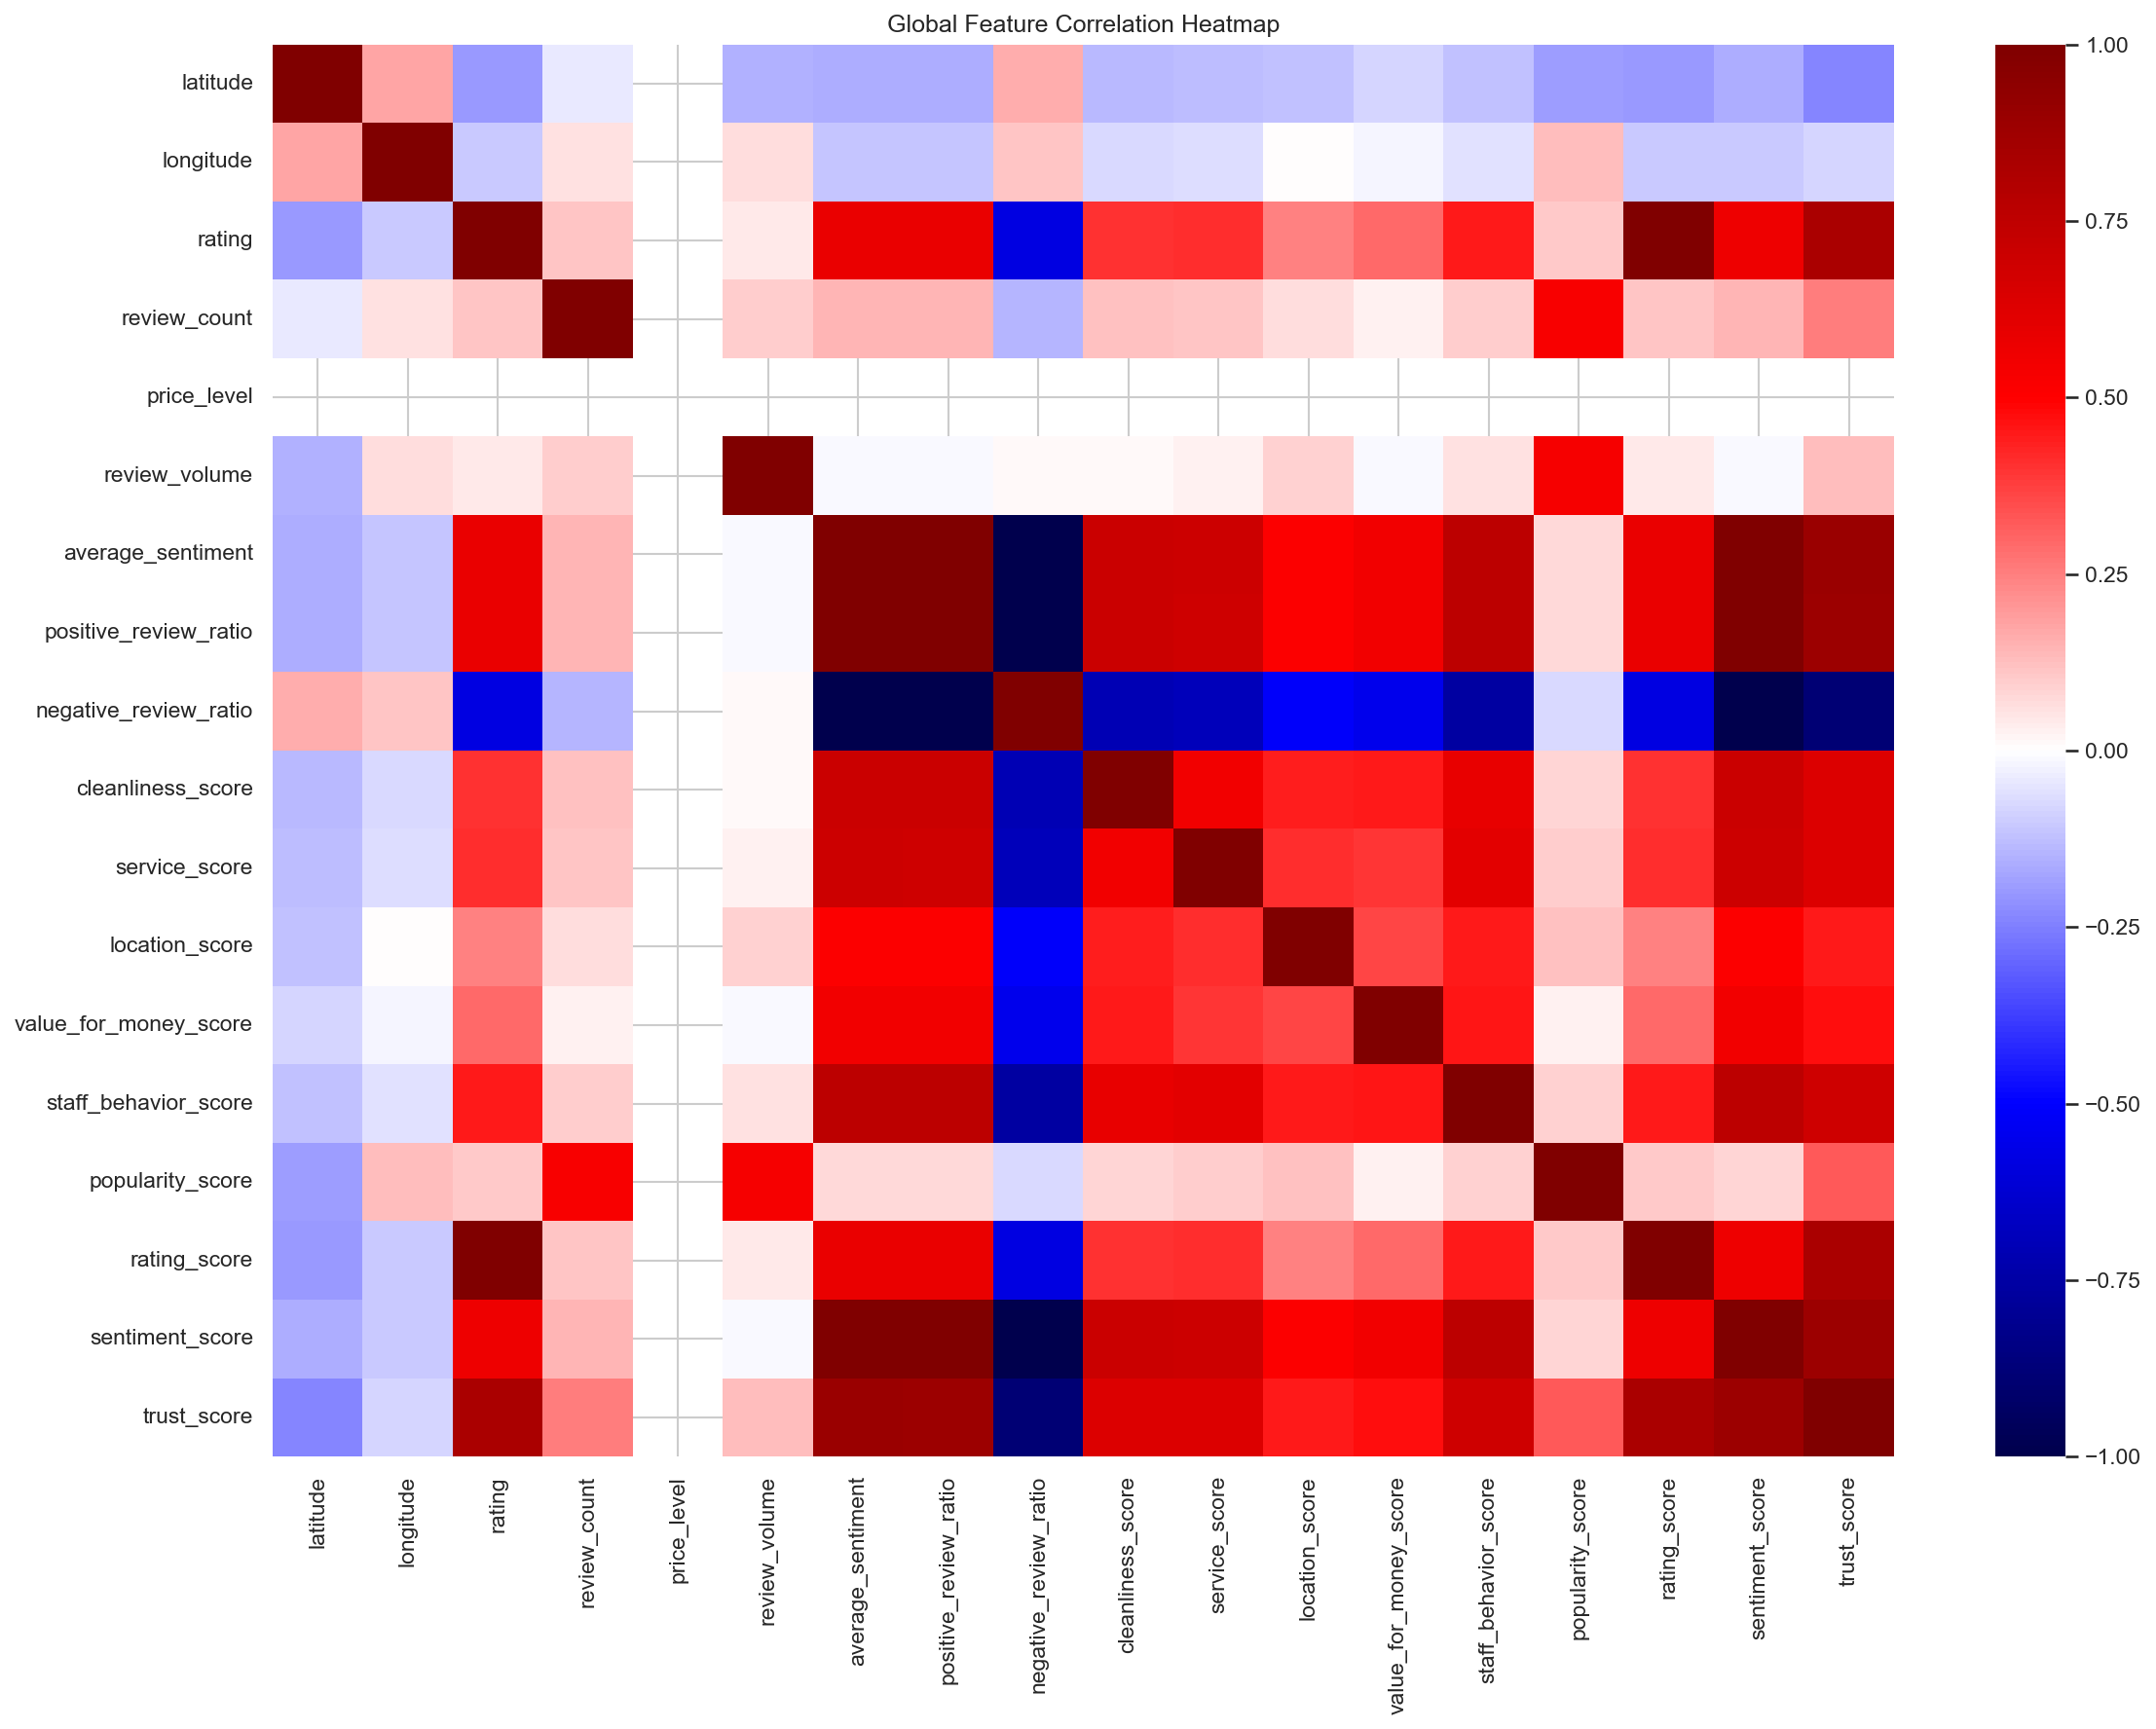

In [4]:
numerical_cols = df_final.select_dtypes(include=[np.number]).columns
corr_matrix = df_final[numerical_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='seismic', vmin=-1, vmax=1)
plt.title('Global Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '08_global_correlation.png'))
plt.show()

**Interpretation & Key Insight:**
> The heatmap reveals key correlations: `trust_score` exhibits positive correlations with NLP aspect sentiments, and is moderately correlated with rating. Rating, count, volume, and sentiment features show strong block correlation structures, meaning they represent a cluster of indicators of hotel performance.

## 4. User Interaction Preference Matches
Checking how synthetic interactions match user preferences.

In [5]:
df_users = pd.read_csv('../../data/raw/synthetic_users/users.csv')
df_int = pd.read_csv('../../data/raw/synthetic_users/interactions.csv')

df_int_merged = pd.merge(df_int, df_users, on='user_id')
df_int_merged = pd.merge(df_int_merged, df_final, on='google_place_id')

# Calculate match percentage for budget preferences
budget_matches = (df_int_merged['budget_preference'] == df_int_merged['budget_category']).mean() * 100
area_matches = (df_int_merged['preferred_area'] == df_int_merged['area']).mean() * 100
print(f'Budget Preference Match Rate in Interactions: {budget_matches:.2f}%')
print(f'Preferred Area Match Rate in Interactions: {area_matches:.2f}%')

Budget Preference Match Rate in Interactions: 43.42%
Preferred Area Match Rate in Interactions: 2.34%


**Interpretation & Key Insight:**
> The interaction-based check shows that user interactions show reasonable overlap with preferred budgets and locations, which confirms that the synthetic generator succeeded in infusing collaborative and content affinity signals. Our recommenders will be able to learn these patterns.